In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt

In [2]:
rmsd = pd.read_csv("/ceph/opig-shared/users/haque/DPhil/ABB4/ABB4/weizmann_with_rmsd.csv")
rmsf = pd.read_csv("/ceph/opig-shared/users/haque/DPhil/ABB4/ABB4/weizmann_with_rmsf.csv")


Spearman correlations: {'CDRH1_mean': np.float64(0.06640165706804128), 'CDRH2_mean': np.float64(0.01624762491048631), 'CDRH3_mean': np.float64(-0.13688826925422284), 'CDRL1_mean': np.float64(-0.05390733532998), 'CDRL2_mean': np.float64(-0.06352956834115295), 'CDRL3_mean': np.float64(-0.04057504480548754)}
Pearson correlations: {'CDRH1_mean': np.float64(0.0493204337795253), 'CDRH2_mean': np.float64(-0.005013940926308949), 'CDRH3_mean': np.float64(-0.08272551231558593), 'CDRL1_mean': np.float64(-0.04815972961450578), 'CDRL2_mean': np.float64(-0.06081991304835237), 'CDRL3_mean': np.float64(-0.029107336671955968)}


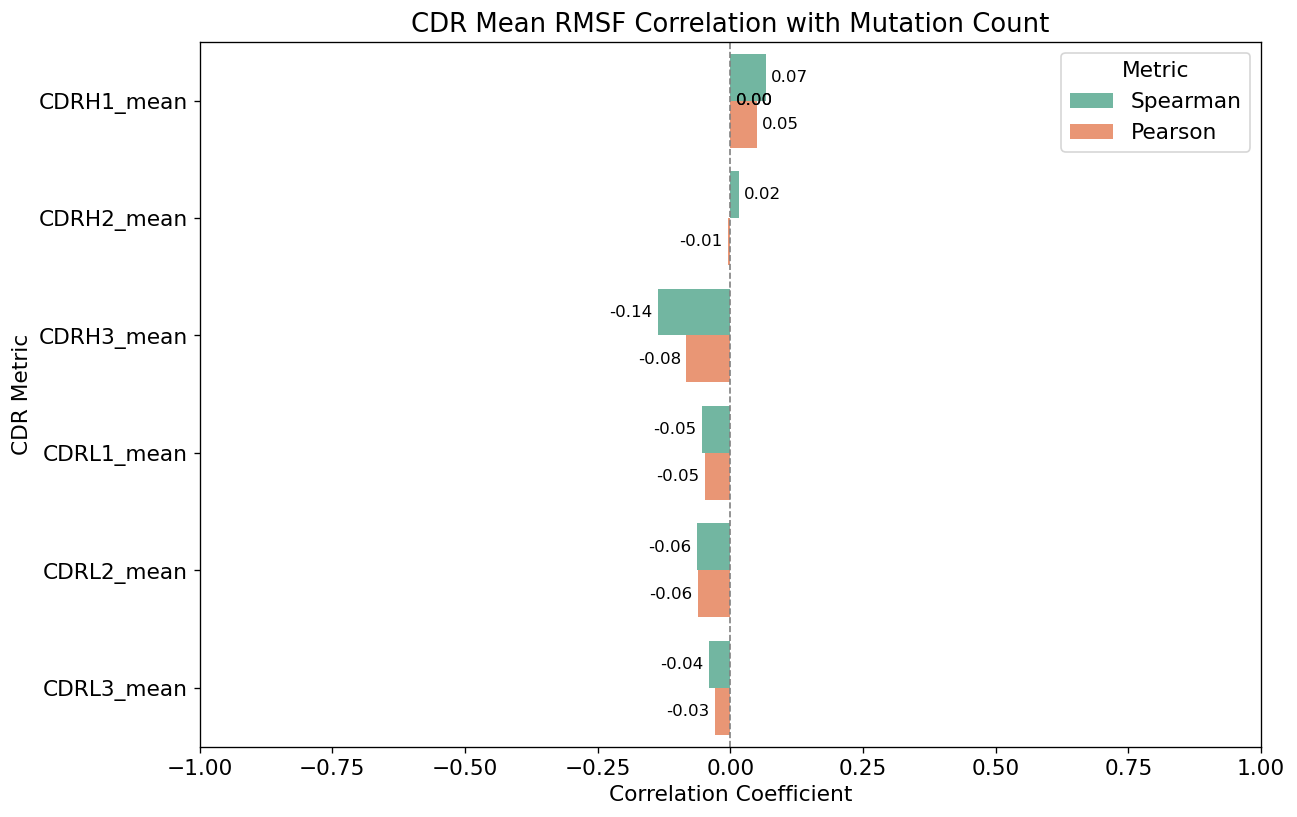

In [3]:
cdr_columns = sorted([col for col in rmsf.columns if col.startswith('CDR') and col.endswith('mean')])
spearman_corr = {}
pearson_corr = {}

for col in cdr_columns:
    spearman_corr[col] = spearmanr(rmsf['Mutations'], rmsf[col])[0]
    pearson_corr[col] = pearsonr(rmsf['Mutations'], rmsf[col])[0]

print("Spearman correlations:", spearman_corr)
print("Pearson correlations:", pearson_corr)

# Build tidy table for plotting
corr_df = pd.DataFrame({
    'CDR': cdr_columns,
    'Spearman': [spearman_corr[c] for c in cdr_columns],
    'Pearson': [pearson_corr[c] for c in cdr_columns],
})

# Keep alphabetical order in the plot
corr_df = corr_df.sort_values('CDR', ascending=True)

plot_df = corr_df.melt(id_vars='CDR', var_name='Correlation Type', value_name='Correlation')

plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(11, 7), dpi=120)
ax = sns.barplot(
    data=plot_df,
    y='CDR',
    x='Correlation',
    hue='Correlation Type',
    palette='Set2'
 )

# Reference line at zero
ax.axvline(0, color='gray', linestyle='--', linewidth=1)

# Label values on bars
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.text(
        width + (0.01 if width >= 0 else -0.01),
        y,
        f'{width:.2f}',
        va='center',
        ha='left' if width >= 0 else 'right',
        fontsize=10
    )

ax.set_title('CDR Mean RMSF Correlation with Mutation Count')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('CDR Metric')
ax.set_xlim(-1, 1)
ax.legend(title='Metric', frameon=True)
plt.tight_layout()
plt.show()

Spearman correlations: {'CDRH1': np.float64(0.05304808633574583), 'CDRH2': np.float64(0.014356790067630989), 'CDRH3': np.float64(-0.08847337045842509), 'CDRL1': np.float64(-0.029177297321853646), 'CDRL2': np.float64(-0.18449846754473417), 'CDRL3': np.float64(-0.02967677213172656)}
Pearson correlations: {'CDRH1': np.float64(0.04280253219112859), 'CDRH2': np.float64(0.0037879713725830376), 'CDRH3': np.float64(-0.0790637586429487), 'CDRL1': np.float64(-0.029058552649358166), 'CDRL2': np.float64(-0.1433053120351419), 'CDRL3': np.float64(-0.0275930026409912)}


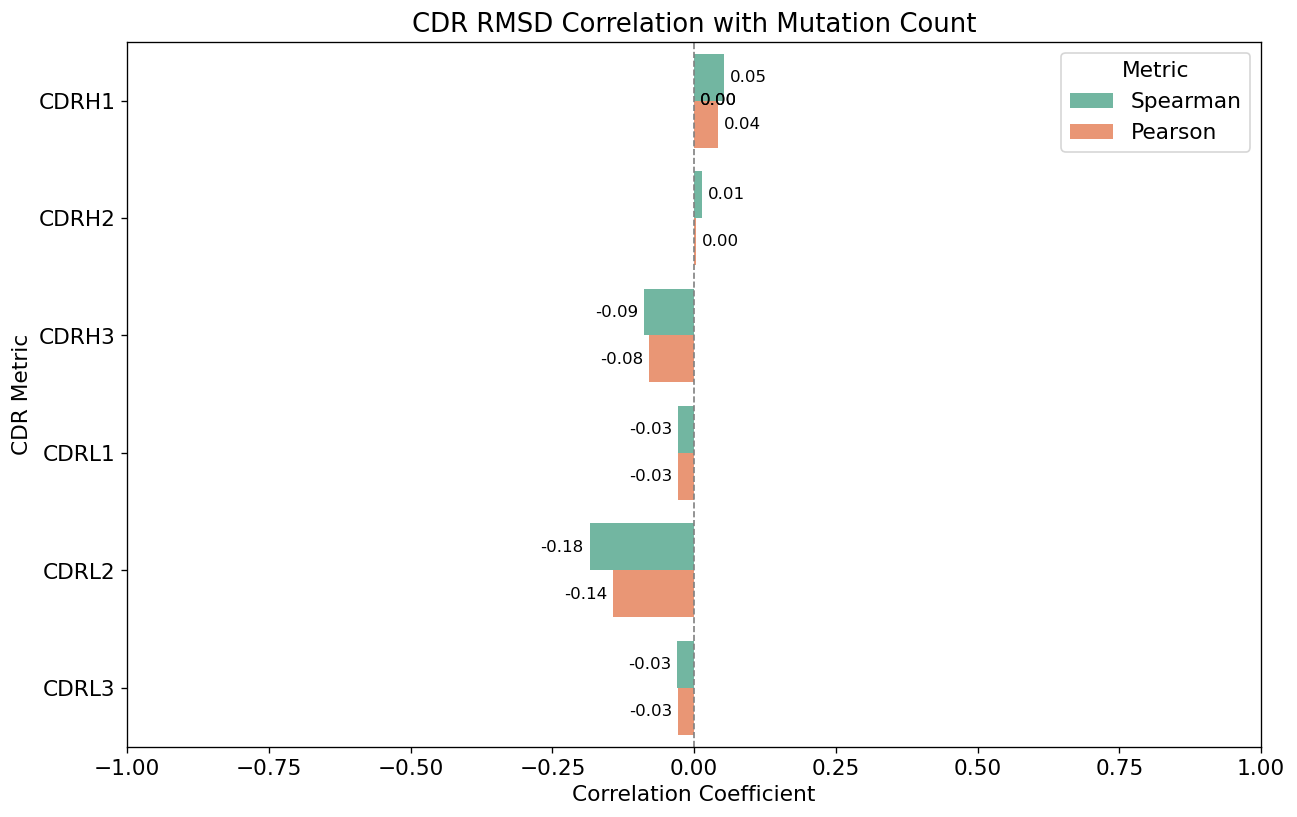

In [4]:
cdr_columns = [col for col in rmsd.columns if col.startswith('CDR')]
spearman_corr = {}
pearson_corr = {}
rmsd_mean_v1 = rmsd[rmsd['type'] == 'mean']
for col in cdr_columns:
    spearman_corr[col] = spearmanr(rmsd_mean_v1['Mutations'], rmsd_mean_v1[col])[0]
    pearson_corr[col] = pearsonr(rmsd_mean_v1['Mutations'], rmsd_mean_v1[col])[0]

print("Spearman correlations:", spearman_corr)
print("Pearson correlations:", pearson_corr)

# Build tidy table for plotting
corr_df = pd.DataFrame({
    'CDR': cdr_columns,
    'Spearman': [spearman_corr[c] for c in cdr_columns],
    'Pearson': [pearson_corr[c] for c in cdr_columns],
})

# Sort by absolute Spearman strength for readability
corr_df = corr_df.sort_values('CDR', ascending=True)


plot_df = corr_df.melt(id_vars='CDR', var_name='Correlation Type', value_name='Correlation')

plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(11, 7), dpi=120)
ax = sns.barplot(
    data=plot_df,
    y='CDR',
    x='Correlation',
    hue='Correlation Type',
    palette='Set2'
 )

# Reference line at zero
ax.axvline(0, color='gray', linestyle='--', linewidth=1)

# Label values on bars
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.text(
        width + (0.01 if width >= 0 else -0.01),
        y,
        f'{width:.2f}',
        va='center',
        ha='left' if width >= 0 else 'right',
        fontsize=10
    )

ax.set_title('CDR RMSD Correlation with Mutation Count')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('CDR Metric')
ax.set_xlim(-1, 1)
ax.legend(title='Metric', frameon=True)
plt.tight_layout()
plt.show()

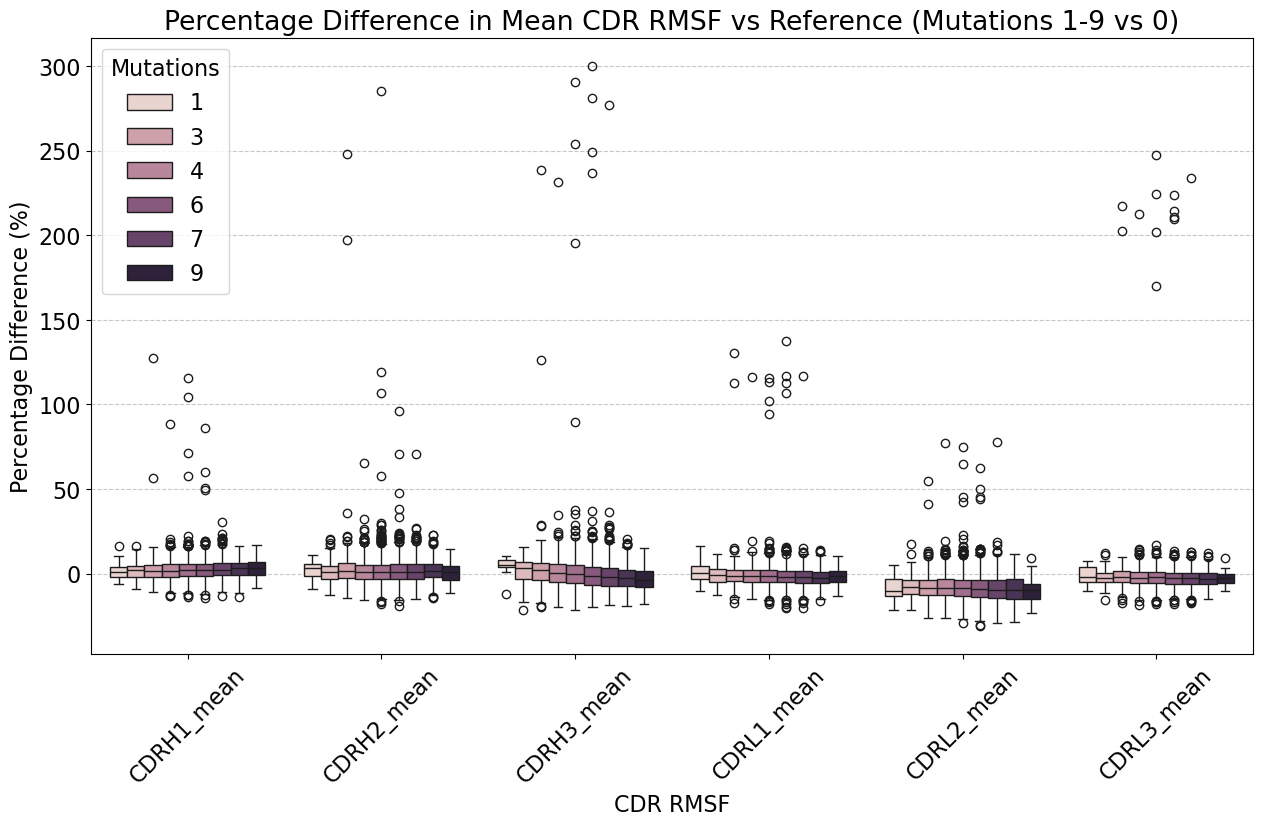

In [5]:
# Identify mean columns and filter the row for mutations 1, 2, 3, 4, 5, 6, 7, 8, 9
cdr_columns = [col for col in rmsf.columns if col.startswith('CDR')]
mean_columns = [col for col in cdr_columns if col.endswith('_mean')]
mutation_levels = [1, 2, 3, 4, 5, 6, 7, 8, 9]
rmsf_filtered = rmsf[rmsf['Mutations'].isin(mutation_levels)]
reference_row = rmsf[rmsf['Mutations'] == 0].iloc[0]

# Calculate percentage differences for mean columns relative to Mutations == 0 reference
perc_diff_mean = rmsf_filtered[mean_columns].apply(
    lambda row: ((row - reference_row[mean_columns]) / reference_row[mean_columns]) * 100, 
    axis=1
)
perc_diff_mean['Mutations'] = rmsf_filtered['Mutations']

# Prepare data for plotting
perc_diff_melted_mean = perc_diff_mean.melt(
    id_vars='Mutations', 
    var_name='CDR RMSF', 
    value_name='Percentage Difference'
)

# Plotting the percentage differences for mean metrics
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(15, 8), dpi = 100)
sns.boxplot(data=perc_diff_melted_mean, x='CDR RMSF', y='Percentage Difference', hue='Mutations')
plt.xticks(rotation=45)
plt.title('Percentage Difference in Mean CDR RMSF vs Reference (Mutations 1-9 vs 0)')
plt.ylabel('Percentage Difference (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [6]:
# 1) Check available columns
print(perc_diff_mean.columns.tolist())

# 2) Pick the CDRH3 percentage-difference column
cdrh3_col = "CDRH3_mean"   # adjust if your exact name differs

# 3) Row with highest (most positive) percentage difference
i_max = perc_diff_mean[cdrh3_col].idxmax()
top_row = perc_diff_mean.loc[i_max, ["Mutations", cdrh3_col]]
print("Highest positive % diff:", top_row.to_dict())

# Optional: highest absolute change (largest magnitude)
i_abs = perc_diff_mean[cdrh3_col].abs().idxmax()
top_abs_row = perc_diff_mean.loc[i_abs, ["Mutations", cdrh3_col]]
print("Largest absolute % diff:", top_abs_row.to_dict())
# from your existing cell
i_max = perc_diff_mean[cdrh3_col].idxmax()

# corresponding row ID + sequence + mutation count
row_meta = rmsf.loc[i_max, ["ID", "Sequence", "Mutations"]]
print(row_meta)

['CDRH1_mean', 'CDRH2_mean', 'CDRH3_mean', 'CDRL1_mean', 'CDRL2_mean', 'CDRL3_mean', 'Mutations']
Highest positive % diff: {'Mutations': 6.0, 'CDRH3_mean': 300.2583865125592}
Largest absolute % diff: {'Mutations': 6.0, 'CDRH3_mean': 300.2583865125592}
ID                                      030101020202030201_pdb
Sequence     DIELTQSPATLSVTPGDSVSLSCRASQSIGNNLHWYQQKSHESPRL...
Mutations                                                    6
Name: 1424, dtype: object


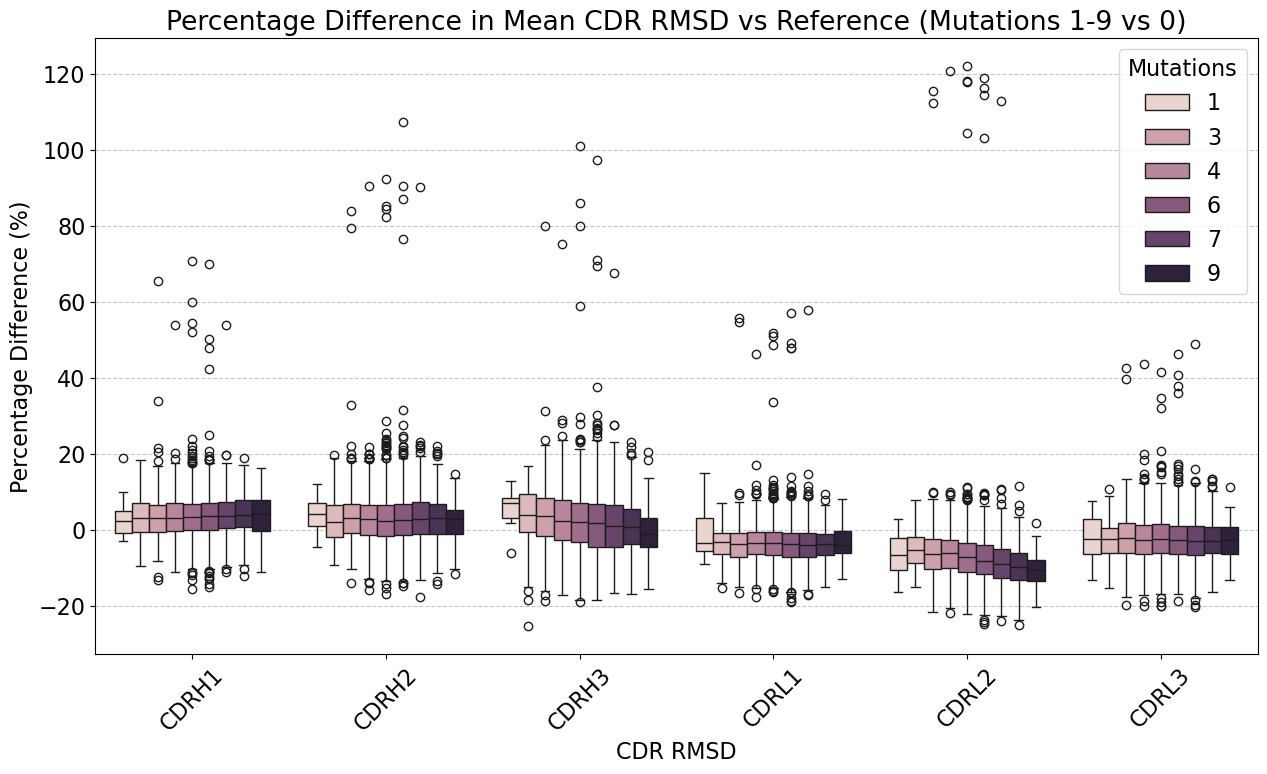

In [7]:
# Identify mean columns and filter the row for mutations 1, 2, 3, 4, 5, 6, 7, 8, 9
cdr_columns_rmsd = [col for col in rmsd.columns if col.startswith('CDR')]
mean_columns = [col for col in cdr_columns_rmsd]
mutation_levels = [1, 2, 3, 4, 5, 6, 7, 8, 9]
rmsd_mean = rmsd[rmsd['type']=='mean']
rmsf_filtered = rmsd_mean[rmsd_mean['Mutations'].isin(mutation_levels)]
reference_row = rmsd_mean[rmsd_mean['Mutations'] == 0].iloc[0]

# Calculate percentage differences for mean columns relative to Mutations == 0 reference
perc_diff_mean = rmsf_filtered[mean_columns].apply(
    lambda row: ((row - reference_row[mean_columns]) / reference_row[mean_columns]) * 100, 
    axis=1
)
perc_diff_mean['Mutations'] = rmsf_filtered['Mutations']

# Prepare data for plotting
perc_diff_melted_mean = perc_diff_mean.melt(
    id_vars='Mutations', 
    var_name='CDR RMSD', 
    value_name='Percentage Difference'
)

# Plotting the percentage differences for mean metrics
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(15, 8), dpi = 100)
sns.boxplot(data=perc_diff_melted_mean, x='CDR RMSD', y='Percentage Difference', hue='Mutations')
plt.xticks(rotation=45)
plt.title('Percentage Difference in Mean CDR RMSD vs Reference (Mutations 1-9 vs 0)')
plt.ylabel('Percentage Difference (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


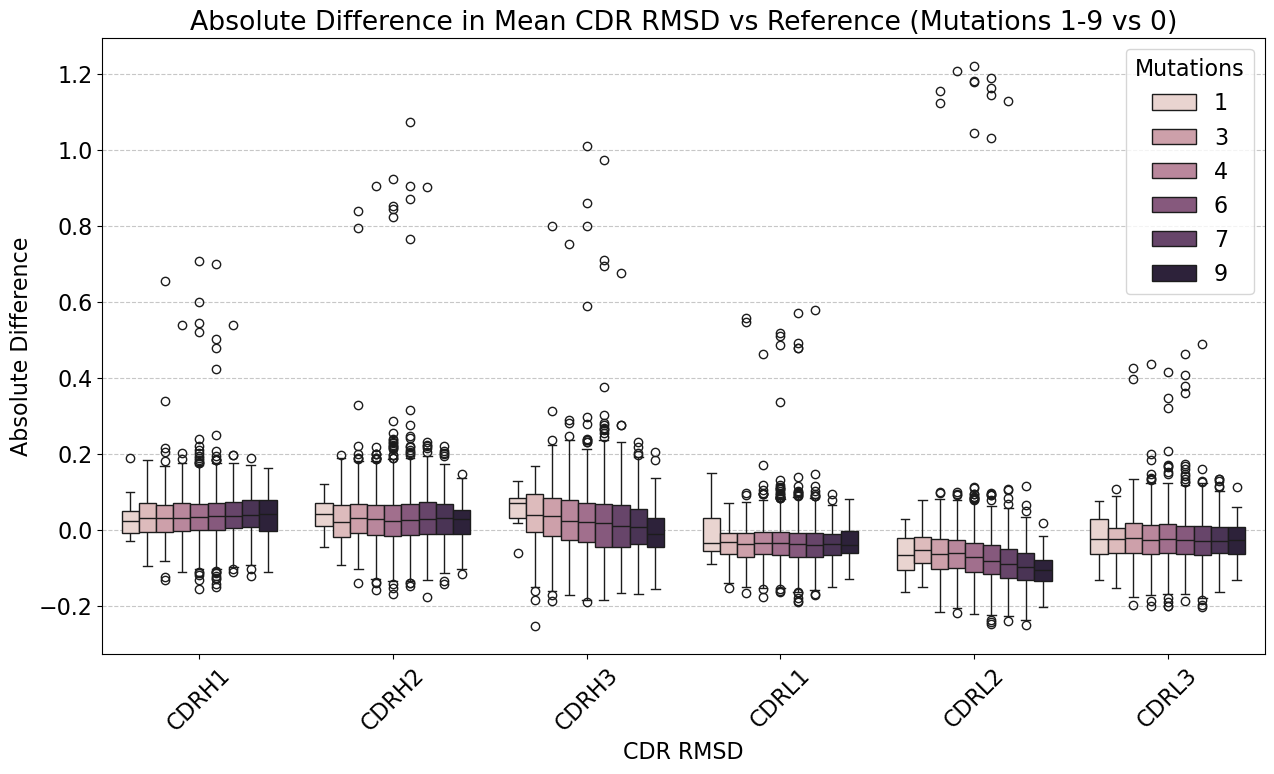

In [8]:
# Identify mean columns and filter the row for mutations 1, 2, 3, 4, 5, 6, 7, 8, 9
cdr_columns_rmsd = [col for col in rmsd.columns if col.startswith('CDR')]
mean_columns = [col for col in cdr_columns_rmsd]
mutation_levels = [1, 2, 3, 4, 5, 6, 7, 8, 9]
rmsd_mean = rmsd[rmsd['type']=='mean']
rmsf_filtered = rmsd_mean[rmsd_mean['Mutations'].isin(mutation_levels)]
reference_row = rmsd_mean[rmsd_mean['Mutations'] == 0].iloc[0]

# Calculate percentage differences for mean columns relative to Mutations == 0 reference
perc_diff_mean = rmsf_filtered[mean_columns].apply(
    lambda row: ((row - reference_row[mean_columns]) / reference_row[mean_columns]), 
    axis=1
)
perc_diff_mean['Mutations'] = rmsf_filtered['Mutations']

# Prepare data for plotting
perc_diff_melted_mean = perc_diff_mean.melt(
    id_vars='Mutations', 
    var_name='CDR RMSD', 
    value_name='Absolute Difference'
)

# Plotting the percentage differences for mean metrics
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(15, 8), dpi = 100)
sns.boxplot(data=perc_diff_melted_mean, x='CDR RMSD', y='Absolute Difference', hue='Mutations')
plt.xticks(rotation=45)
plt.title('Absolute Difference in Mean CDR RMSD vs Reference (Mutations 1-9 vs 0)')
plt.ylabel('Absolute Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


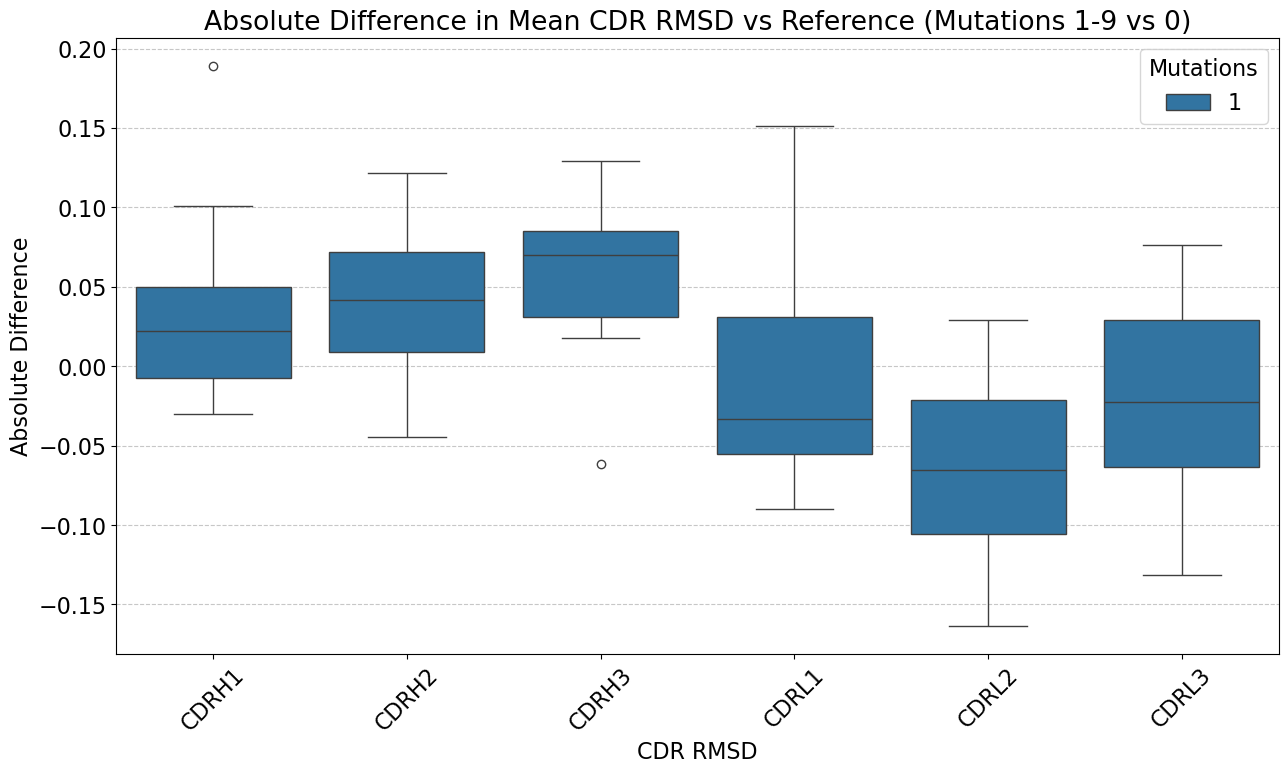

In [9]:
# Identify mean columns and filter the row for mutations 1, 2, 3, 4, 5, 6, 7, 8, 9
cdr_columns_rmsd = [col for col in rmsd.columns if col.startswith('CDR')]
mean_columns = [col for col in cdr_columns_rmsd]
mutation_levels = [1]
rmsd_mean = rmsd[rmsd['type']=='mean']
rmsf_filtered = rmsd_mean[rmsd_mean['Mutations'].isin(mutation_levels)]
reference_row = rmsd_mean[rmsd_mean['Mutations'] == 0].iloc[0]

# Calculate percentage differences for mean columns relative to Mutations == 0 reference
perc_diff_mean = rmsf_filtered[mean_columns].apply(
    lambda row: ((row - reference_row[mean_columns]) / reference_row[mean_columns]), 
    axis=1
)
perc_diff_mean['Mutations'] = rmsf_filtered['Mutations']

# Prepare data for plotting
perc_diff_melted_mean = perc_diff_mean.melt(
    id_vars='Mutations', 
    var_name='CDR RMSD', 
    value_name='Absolute Difference'
)

# Plotting the percentage differences for mean metrics
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(15, 8), dpi = 100)
sns.boxplot(data=perc_diff_melted_mean, x='CDR RMSD', y='Absolute Difference', hue='Mutations')
plt.xticks(rotation=45)
plt.title('Absolute Difference in Mean CDR RMSD vs Reference (Mutations 1-9 vs 0)')
plt.ylabel('Absolute Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


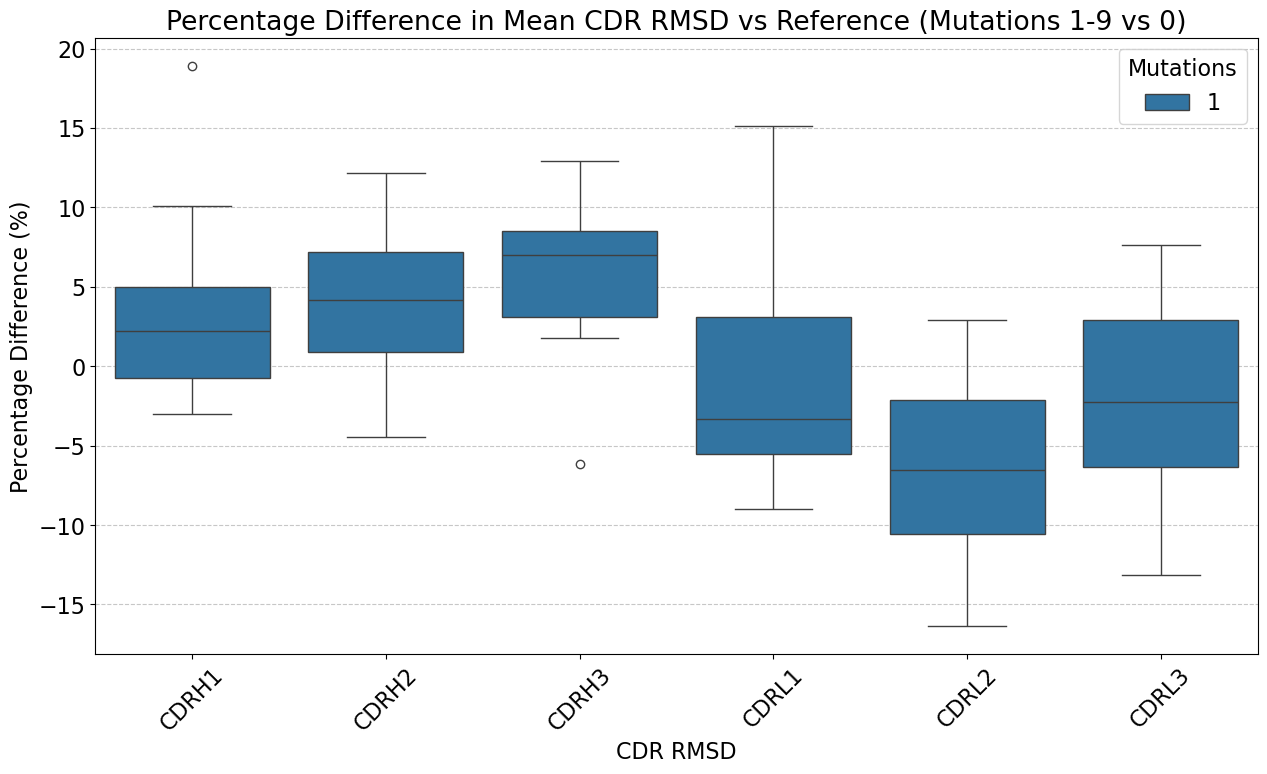

In [10]:
# Identify mean columns and filter the row for mutations 1, 2, 3, 4, 5, 6, 7, 8, 9
cdr_columns_rmsd = [col for col in rmsd.columns if col.startswith('CDR')]
mean_columns = [col for col in cdr_columns_rmsd]
mutation_levels = [1]
rmsd_mean = rmsd[rmsd['type']=='mean']
rmsf_filtered = rmsd_mean[rmsd_mean['Mutations'].isin(mutation_levels)]
reference_row = rmsd_mean[rmsd_mean['Mutations'] == 0].iloc[0]

# Calculate percentage differences for mean columns relative to Mutations == 0 reference
perc_diff_mean = rmsf_filtered[mean_columns].apply(
    lambda row: ((row - reference_row[mean_columns]) / reference_row[mean_columns]) * 100, 
    axis=1
)
perc_diff_mean['Mutations'] = rmsf_filtered['Mutations']

# Prepare data for plotting
perc_diff_melted_mean = perc_diff_mean.melt(
    id_vars='Mutations', 
    var_name='CDR RMSD', 
    value_name='Percentage Difference'
)

# Plotting the percentage differences for mean metrics
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(15, 8), dpi = 100)
sns.boxplot(data=perc_diff_melted_mean, x='CDR RMSD', y='Percentage Difference', hue='Mutations')
plt.xticks(rotation=45)
plt.title('Percentage Difference in Mean CDR RMSD vs Reference (Mutations 1-9 vs 0)')
plt.ylabel('Percentage Difference (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Load mutation annotations and harmonize IDs (notebook IDs have '_pdb' suffix).
ann = pd.read_csv("/ceph/opig-shared/users/haque/DPhil/ABB4/ABB4/weizmann_with_mutation_annotations.csv")

rmsd_mean = rmsd[rmsd["type"] == "mean"].copy()
rmsd_mean["ID_base"] = rmsd_mean["ID"].astype(str).str.replace("_pdb$", "", regex=True)

ann = ann.copy()
ann["ID_base"] = ann["ID"].astype(str)

merged = rmsd_mean.merge(
    ann,
    on="ID_base",
    how="left",
    suffixes=("_rmsd", "_ann"),
)

# Build CDR matrix for WT (Mutations=0) + all Mutations=1 IDs.
cdr_cols = sorted([c for c in rmsd_mean.columns if c.startswith("CDR")])
wt_rows = merged[merged["Mutations"] == 0].copy()
mut1_rows = merged[merged["Mutations"] == 1].copy()

if wt_rows.empty:
    raise ValueError("No WT row found (Mutations == 0) in RMSD mean data.")

# Keep one WT reference row at the top, then all mutation=1 rows.
wt_row = wt_rows.iloc[[0]].copy()
wt_row["plot_label"] = "WT (Mutations=0)"
mut1_rows["plot_label"] = mut1_rows["ID"].astype(str)

plot_rows = pd.concat([wt_row, mut1_rows], ignore_index=True)

heatmap_df = plot_rows.set_index("plot_label")[cdr_cols]

plt.figure(figsize=(14, max(6, 0.35 * len(heatmap_df))))
sns.heatmap(
    heatmap_df,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Mean RMSD"},
)
plt.title("CDR Mean RMSD Map: WT + All IDs with 1 Mutation")
plt.xlabel("CDRs")
plt.ylabel("Sequences (WT at top)")
plt.tight_layout()
plt.show()

# Correlation across CDRs for only mutation=1 IDs.
corr_mut1 = mut1_rows[cdr_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_mut1,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Correlation of CDR Flexibility Across Mutation=1 IDs")
plt.tight_layout()
plt.show()

print(f"Plotted {len(mut1_rows)} mutation=1 IDs plus 1 WT row.")

In [ ]:
# Build a mutation-details table for the plotted sequences.
# This attempts to surface annotation columns that likely contain mutation descriptions.
candidate_cols = [
    "ID",
    "Sequence",
    "Mutations",
    "Mutation",
    "Mutations_List",
    "Mutation_List",
    "Mutation_Annotation",
    "Mutation_Annotations",
    "mutations",
    "mutation",
    "annotation",
]

ann_cols_present = [c for c in candidate_cols if c in merged.columns]

if not ann_cols_present:
    # Fallback: keep all annotation-side columns if no obvious mutation column name is found.
    ann_only_cols = [
        c for c in merged.columns
        if c.endswith("_ann") or c in ann.columns or c in ["ID_base"]
    ]
    ann_cols_present = [c for c in ann_only_cols if c in merged.columns]

mut1_table = merged[merged["Mutations"] == 1].copy()

# Prefer notebook ID (with _pdb) plus base ID and selected annotation fields.
front_cols = [c for c in ["ID", "ID_base", "Mutations"] if c in mut1_table.columns]
table_cols = front_cols + [c for c in ann_cols_present if c not in front_cols]

mut1_table = (
    mut1_table[table_cols]
    .drop_duplicates()
    .sort_values(by=[c for c in ["ID", "ID_base"] if c in table_cols])
    .reset_index(drop=True)
)

print(f"Mutation details table contains {len(mut1_table)} rows.")
display(mut1_table)